In [1]:
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
import timm

d:\Crop Identification Dataset\cropIdentification\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_PATH = "models/crop_identifier_best.pth"
CLASS_PATH = "classes.json"
IMAGE_SIZE = 224
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device :", DEVICE)

Device : cuda


In [3]:
with open(CLASS_PATH) as f:
    class_names = json.load(f)

print(class_names)

['BellPepper', 'Chilli', 'Cotton', 'Groundnut', 'Potato', 'Tomato']


In [4]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),      # First resize to 256x256
    transforms.CenterCrop(224),         # Then center-crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [6]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=len(class_names)
)

# Load the checkpoint file and extract the 'model' key
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])

model.to(DEVICE)
model.eval()
print("Model Loaded")

Model Loaded


In [7]:
def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0)
    tensor = tensor.to(DEVICE)
    start = time.time()
    with torch.no_grad():
        output = model(tensor)
        probs = F.softmax(output,dim=1)
    end = time.time()
    inference_time = (end-start)*1000
    probs = probs.cpu().numpy()[0]
    return image, probs, inference_time

In [8]:
def show_prediction(image_path):
    image, probs, inference_time = predict(image_path)
    top3 = np.argsort(probs)[::-1][:3]
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{class_names[top3[0]]}\n"
        f"{probs[top3[0]]*100:.2f}%"
    )
    plt.show()
    print()
    print("Prediction")
    print("-"*40)
    for idx in top3:
        print(
            f"{class_names[idx]:15}"
            f"{probs[idx]*100:.2f}%"
        )
    print()
    print(
        f"Inference Time : {inference_time:.2f} ms"
    )

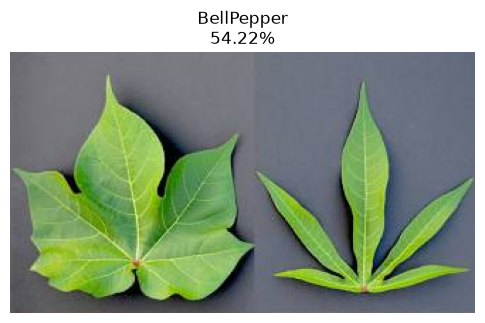


Prediction
----------------------------------------
BellPepper     54.22%
Cotton         33.36%
Potato         7.49%

Inference Time : 321.98 ms


In [9]:
IMAGE_PATH = "sample.jpg"
show_prediction(IMAGE_PATH)

In [10]:
def predict_folder(folder):
    folder = Path(folder)
    images = []
    for ext in [
        "*.jpg",
        "*.jpeg",
        "*.png"
    ]:
        images.extend(folder.glob(ext))
    for img in images:
        image, probs, _ = predict(img)
        pred = np.argmax(probs)
        confidence = probs[pred]

        if confidence < 0.70:
            prediction = "Uncertain"
        else:
            prediction = class_names[pred]

        print(
            img.name,
            "->",
            prediction,
            f"({confidence*100:.2f}%)"
        )


In [11]:
predict_folder("test_images")

chilli.jpg -> Uncertain (48.52%)
cotton.jpg -> Uncertain (66.20%)
groundnut.jpg -> Uncertain (66.29%)
potato.jpg -> Potato (82.66%)
tomato.jpg -> Uncertain (43.33%)
bellpepper.jpeg -> Uncertain (46.90%)


In [12]:
def prediction_card(image_path):
    image, probs, time_taken = predict(image_path)
    pred = np.argmax(probs)
    plt.figure(figsize=(7,7))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"""
Crop : {class_names[pred]}
Confidence : {probs[pred]*100:.2f}%
Inference : {time_taken:.2f} ms
"""
    )
    plt.show()

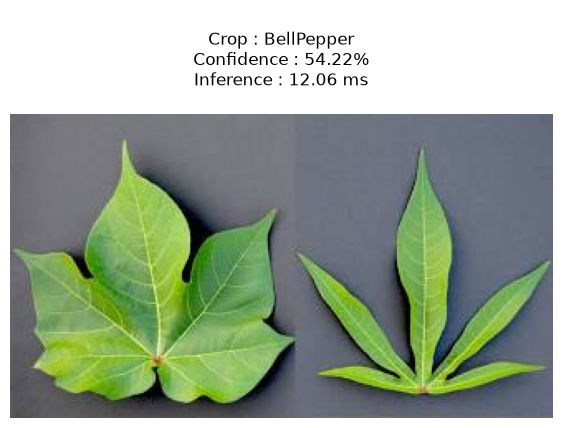

In [13]:
prediction_card("sample.jpg")

In [14]:
from pandas.core import resample
from pandas.core import resample
def save_prediction(image_path):
    image, probs, t = predict(image_path)
    pred = np.argmax(probs)
    result = {
        "crop": class_names[pred],
        "confidence": float(
            probs[pred]
        ),
        "inference_ms": float(t)
    }
    with open(
        "prediction.json",
        "w"
    ) as f:
        json.dump(
            result,
            f,
            indent=4
        )
    print(result)

save_prediction("test_images/cotton.jpg")

{'crop': 'Cotton', 'confidence': 0.6619912385940552, 'inference_ms': 11.220932006835938}
